<a href="https://colab.research.google.com/github/Himanshu0518/Sales-Analytics-Customer-Behavior-Dashboard/blob/main/RFM_analysis_sales_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

In [3]:
df=pd.read_csv('/content/Orders.csv',sep=';', on_bad_lines='skip')
df.head(2)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Segment,Postal Code,Product ID,Sales,Quantity,Discount,Profit
0,1,CA-2022-152156,08/11/2022,11/11/2022,Second Class,CG-12520,Consumer,42420,FUR-BO-10001798,"261,96",2,0,"41,9136"
1,2,CA-2022-152156,08/11/2022,11/11/2022,Second Class,CG-12520,Consumer,42420,FUR-CH-10000454,"731,94",3,0,"219,582"


### Data Preparation for RFM Analysis

First, I'll convert the 'Order Date' column to a datetime format and the 'Sales' column to a numeric type, as it currently uses a comma as a decimal separator. This ensures the data is suitable for calculations.

In [4]:
df['Order Date'] = pd.to_datetime(df['Order Date'], format='%d/%m/%Y')
df['Sales'] = df['Sales'].str.replace(',', '.').astype(float)

display(df.head())

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Segment,Postal Code,Product ID,Sales,Quantity,Discount,Profit
0,1,CA-2022-152156,2022-11-08,11/11/2022,Second Class,CG-12520,Consumer,42420,FUR-BO-10001798,261.9600,2,0,"41,9136"
1,2,CA-2022-152156,2022-11-08,11/11/2022,Second Class,CG-12520,Consumer,42420,FUR-CH-10000454,731.9400,3,0,"219,582"
2,3,CA-2022-138688,2022-06-12,16/06/2022,Second Class,DV-13045,Corporate,90036,OFF-LA-10000240,14.6200,2,0,"6,8714"
3,4,US-2021-108966,2021-10-11,18/10/2021,Standard Class,SO-20335,Consumer,33311,FUR-TA-10000577,957.5775,5,"0,45","-383,031"
4,5,US-2021-108966,2021-10-11,18/10/2021,Standard Class,SO-20335,Consumer,33311,OFF-ST-10000760,22.3680,2,"0,2","2,5164"


### Calculate Recency

Recency is the number of days since the customer's last purchase. To calculate this, I'll find the most recent order date in the entire dataset and then subtract each customer's last purchase date from it. This defines how 'recent' a customer's activity is.

In [5]:
max_date = df['Order Date'].max()
rfm_recency = df.groupby('Customer ID')['Order Date'].max().reset_index()
rfm_recency['Recency'] = (max_date - rfm_recency['Order Date']).dt.days

display(rfm_recency.head())

,Customer ID,Order Date,Recency
0,AA-10315,2023-06-29,184
1,AA-10375,2023-12-11,19
2,AA-10480,2023-04-15,259
3,AA-10645,2023-11-05,55
4,AB-10015,2022-11-10,415


### Calculate Frequency

Frequency is the total number of orders made by each customer. I'll count the unique 'Order ID's for each 'Customer ID' to determine this value.

In [6]:
rfm_frequency = df.groupby('Customer ID')['Order ID'].nunique().reset_index()
rfm_frequency.columns = ['Customer ID', 'Frequency']

display(rfm_frequency.head())

,Customer ID,Frequency
0,AA-10315,5
1,AA-10375,9
2,AA-10480,4
3,AA-10645,6
4,AB-10015,3


### Calculate Monetary

Monetary represents the total revenue generated by each customer. I'll sum the 'Sales' for each 'Customer ID' to get this metric.

In [7]:
rfm_monetary = df.groupby('Customer ID')['Sales'].sum().reset_index()
rfm_monetary.columns = ['Customer ID', 'Monetary']

display(rfm_monetary.head())

,Customer ID,Monetary
0,AA-10315,5563.560
1,AA-10375,1056.390
2,AA-10480,1790.512
3,AA-10645,5086.935
4,AB-10015,886.156


### Combine RFM Metrics

Now, I'll merge the Recency, Frequency, and Monetary dataframes into a single RFM dataframe, using 'Customer ID' as the key. This consolidated dataframe will be the basis for our RFM scoring and segmentation.

In [8]:
rfm = rfm_recency.merge(rfm_frequency, on='Customer ID')
rfm = rfm.merge(rfm_monetary, on='Customer ID')

# Drop the 'Order Date' column from the RFM dataframe as it's no longer needed after calculating Recency
rfm = rfm.drop(columns=['Order Date'])

display(rfm.head())

,Customer ID,Recency,Frequency,Monetary
0,AA-10315,184,5,5563.560
1,AA-10375,19,9,1056.390
2,AA-10480,259,4,1790.512
3,AA-10645,55,6,5086.935
4,AB-10015,415,3,886.156


### RFM Scoring

To effectively segment customers, I'll assign scores from 1 to 5 for Recency, Frequency, and Monetary values. For Recency, lower values (more recent purchases) will get higher scores. For Frequency and Monetary, higher values will get higher scores. This scoring will be based on quintiles.

In [9]:
# Assign scores from 1 to 5 for Recency, Frequency, and Monetary
# For Recency: lower the value, higher the score
rfm['R_Score'] = pd.qcut(rfm['Recency'], 5, labels=[5, 4, 3, 2, 1])

# For Frequency and Monetary: higher the value, higher the score
rfm['F_Score'] = pd.qcut(rfm['Frequency'], 5, labels=[1, 2, 3, 4, 5])
rfm['M_Score'] = pd.qcut(rfm['Monetary'], 5, labels=[1, 2, 3, 4, 5])

display(rfm.head())

,Customer ID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score
0,AA-10315,184,5,5563.560,2,2,5
1,AA-10375,19,9,1056.390,5,5,2
2,AA-10480,259,4,1790.512,1,1,3
3,AA-10645,55,6,5086.935,3,3,5
4,AB-10015,415,3,886.156,1,1,1


### Combine RFM Scores

After individual scoring, I'll combine the R, F, and M scores to create an overall RFM score and also an RFM segment. This will allow for a clearer classification of customers.

In [10]:
rfm['RFM_Score'] = rfm['R_Score'].astype(str) + rfm['F_Score'].astype(str) + rfm['M_Score'].astype(str)
rfm['RFM_Sum'] = rfm['R_Score'].astype(int) + rfm['F_Score'].astype(int) + rfm['M_Score'].astype(int)

display(rfm.head())

,Customer ID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,RFM_Sum
0,AA-10315,184,5,5563.560,2,2,5,225,9
1,AA-10375,19,9,1056.390,5,5,2,552,12
2,AA-10480,259,4,1790.512,1,1,3,113,5
3,AA-10645,55,6,5086.935,3,3,5,335,11
4,AB-10015,415,3,886.156,1,1,1,111,3


### Customer Segmentation

Now, I'll define customer segments based on their RFM scores. This will categorize customers into groups such as 'Champions', 'Loyal Customers', 'At Risk', etc., providing actionable insights.

In [11]:
def rfm_segment(df):
    if df['RFM_Sum'] >= 13: # Top 20% of scores (e.g., 555, 545, 455, 554, 544, 454, 445)
        return 'Champions'
    elif df['RFM_Sum'] >= 10: # Next 20% - 40%
        return 'Loyal Customers'
    elif df['RFM_Sum'] >= 7: # Next 40% - 60%
        return 'Potential Loyalist'
    elif df['RFM_Sum'] >= 4: # Next 60% - 80%
        return 'At Risk'
    else: # Bottom 20%
        return 'Churned Customers'

rfm['Customer_Segment'] = rfm.apply(rfm_segment, axis=1)

display(rfm.head())

,Customer ID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,RFM_Sum,Customer_Segment
0,AA-10315,184,5,5563.560,2,2,5,225,9,Potential Loyalist
1,AA-10375,19,9,1056.390,5,5,2,552,12,Loyal Customers
2,AA-10480,259,4,1790.512,1,1,3,113,5,At Risk
3,AA-10645,55,6,5086.935,3,3,5,335,11,Loyal Customers
4,AB-10015,415,3,886.156,1,1,1,111,3,Churned Customers


### Analyze Customer Segments

To understand the characteristics of each segment, I'll count the number of customers in each segment and calculate the average RFM values. This will give us a clear picture of each group's behavior.

In [13]:
segment_counts = rfm['Customer_Segment'].value_counts().reset_index()
segment_counts.columns = ['Segment', 'Number of Customers']

segment_averages = rfm.groupby('Customer_Segment')[['Recency', 'Frequency', 'Monetary', 'RFM_Sum']].mean().reset_index()

display(segment_counts)
display(segment_averages)

,Segment,Number of Customers
0,Loyal Customers,248
1,Potential Loyalist,225
2,At Risk,162
3,Champions,113
4,Churned Customers,45


,Customer_Segment,Recency,Frequency,Monetary,RFM_Sum
0,At Risk,268.351852,4.061728,1167.773430,5.135802
1,Champions,27.743363,9.663717,5264.525572,13.690265
2,Churned Customers,494.955556,2.733333,406.778782,3.000000
3,Loyal Customers,70.483871,7.504032,3926.673951,10.887097
4,Potential Loyalist,133.453333,5.666667,2315.599956,8.017778


### Visualize Customer Segment Distribution

This bar plot illustrates the number of customers in each defined segment, providing an immediate overview of your customer base's composition.

/tmp/ipykernel_1175/695960359.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Segment', y='Number of Customers', data=segment_counts, palette='viridis')


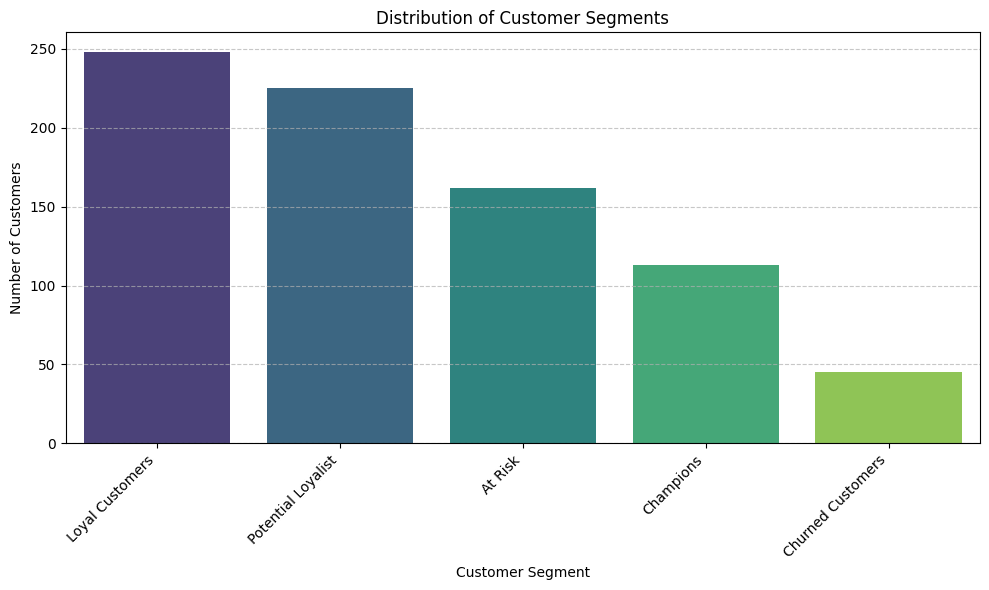

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.barplot(x='Segment', y='Number of Customers', data=segment_counts, palette='viridis')
plt.title('Distribution of Customer Segments')
plt.xlabel('Customer Segment')
plt.ylabel('Number of Customers')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Visualize Average RFM Values per Segment

These bar plots show the average Recency, Frequency, and Monetary values for each customer segment. This helps in understanding the distinct behaviors of each group identified by the RFM model.

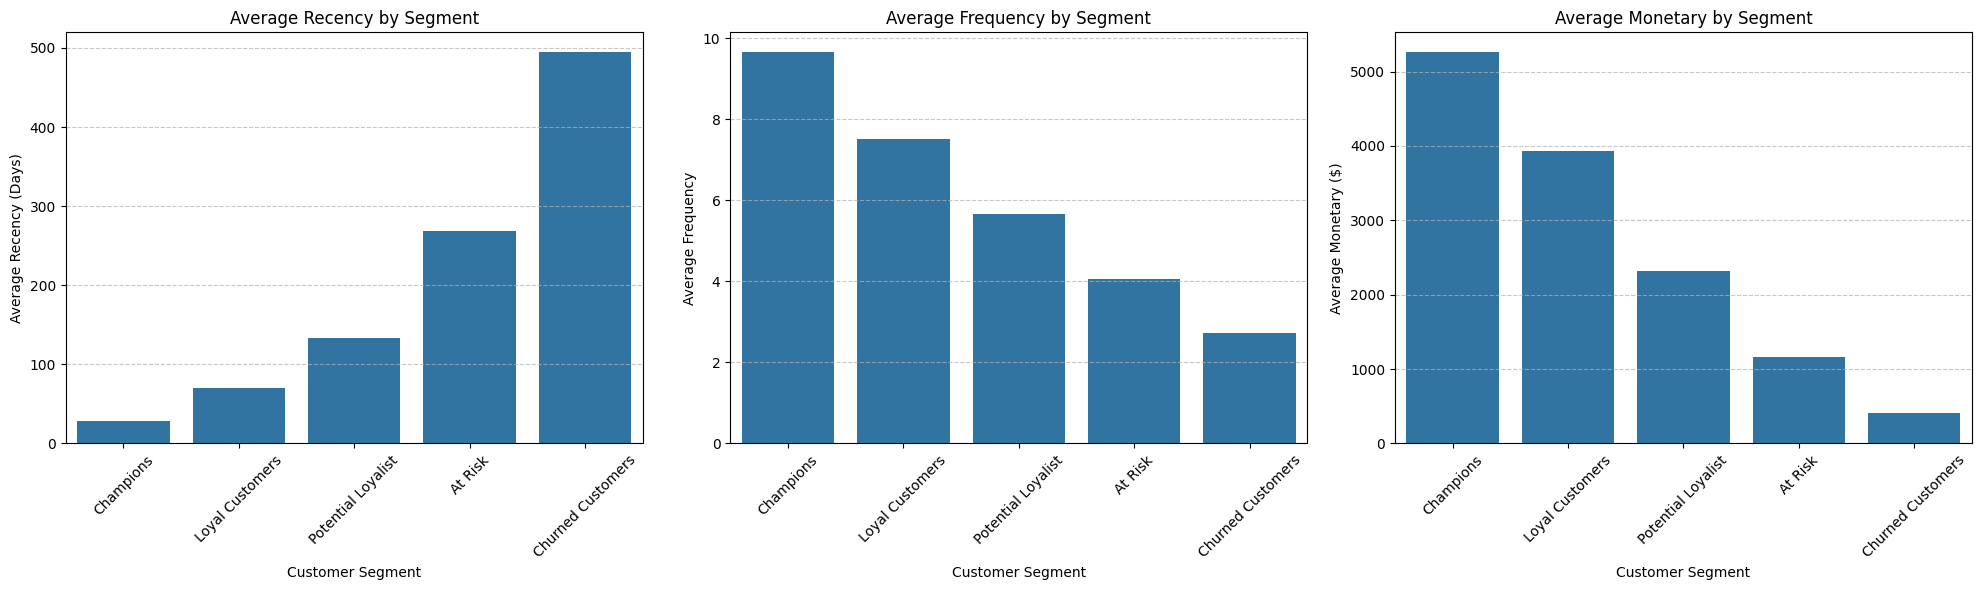

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6), sharey=False)

sns.barplot(x='Customer_Segment', y='Recency', data=segment_averages.sort_values('Recency'), ax=axes[0])
axes[0].set_title('Average Recency by Segment')
axes[0].set_xlabel('Customer Segment')
axes[0].set_ylabel('Average Recency (Days)')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

sns.barplot(x='Customer_Segment', y='Frequency', data=segment_averages.sort_values('Frequency', ascending=False), ax=axes[1])
axes[1].set_title('Average Frequency by Segment')
axes[1].set_xlabel('Customer Segment')
axes[1].set_ylabel('Average Frequency')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

sns.barplot(x='Customer_Segment', y='Monetary', data=segment_averages.sort_values('Monetary', ascending=False), ax=axes[2])
axes[2].set_title('Average Monetary by Segment')
axes[2].set_xlabel('Customer Segment')
axes[2].set_ylabel('Average Monetary ($)')
axes[2].tick_params(axis='x', rotation=45)
axes[2].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()